This notebook is focusing on finding optimal setting for the parameters of Unscented Kalman filter, alpha, beta, kappa.

According to 

https://www.eecs.yorku.ca/course_archive/2017-18/W/4421/lectures/Unscented%20kalman%20filter%20-%20annotated.pdf
https://se.mathworks.com/help/control/ug/extended-and-unscented-kalman-filter-algorithms-for-online-state-estimation.html

- alpha takes the value between $0 ≤ α ≤ 1$
- beta, by default, is 0 or 2 if the distribution of the state is Gaussian
- kappa is normally set to 0 or $n_{x}$ + κ = 3, where $n_{x}$ is dimension of the system's state

In [1]:
import os
import sys
import numpy as np
import pandas as pd
sys.path.append('/app/src')
from data_loader import DataLoader
from configs import SetupEnum, ErrorEnum
from parameter_tuners.unscented_kalaman_filter_parameter_tuner import UnscentedKalmanFilterParameterTuner


%matplotlib inline
np.random.seed(777)

In [2]:
alphas = np.logspace(-4, 0, 5).tolist()

params = {
    "alphas": alphas
}
params

{'alphas': [0.0001, 0.001, 0.01, 0.1, 1.0]}

In [3]:
root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
file_export_path = os.path.join(root_path, "exports/unscented_kalman_filter")

exporting_filename = os.path.join(file_export_path, "0016_best_params.json")

kitti_date = '2011_09_30'
kitti_drive = '0016'

run_filter = False
error_type = ErrorEnum.MAE

In [4]:
best_params = []
best_params_0 = []
best_params_10 = []
best_params_20 = []
best_params_30 = []
best_params_40 = []

---

# No dropout measurement data

## Setup1(IMU, VO)

In [5]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=0.0,
    visualize_data=False)

tuner_setup1 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup1.run()
else:
    tuner_setup1.load_df()

Data sampling is set to normal mode.


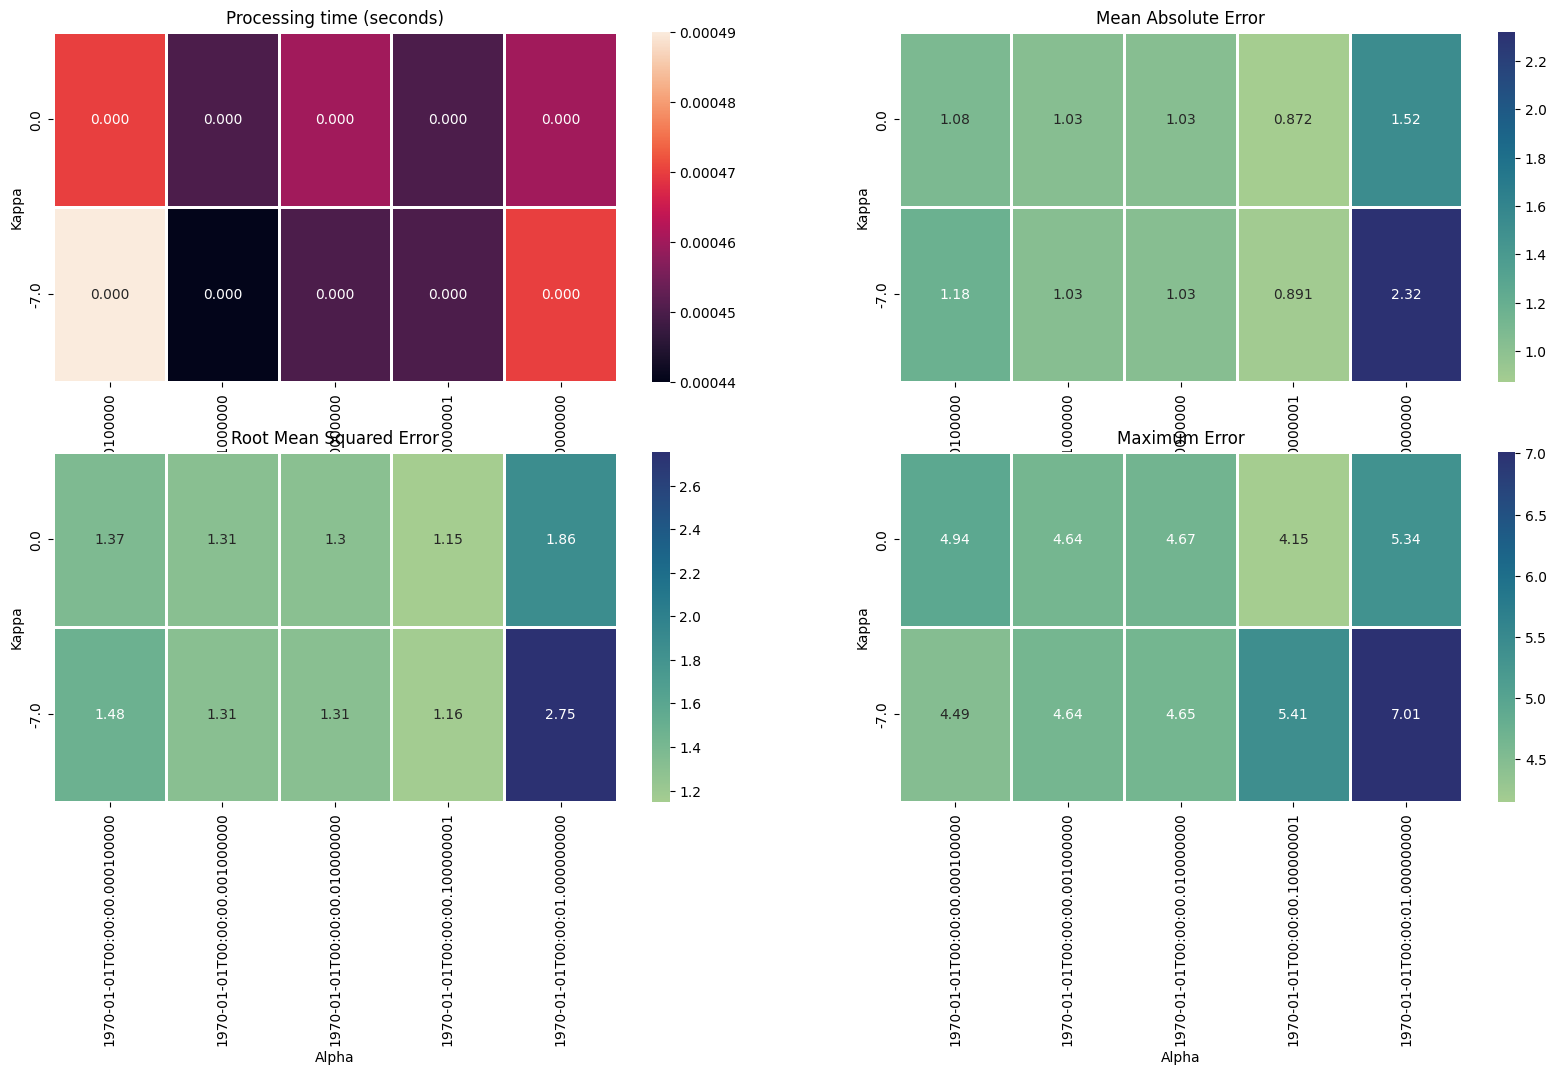

In [6]:
tuner_setup1.plot_results()

In [7]:
best_combination_setup1_0 = tuner_setup1.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.872
Processing time: 0.0
Alpha: 0.1
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 1.148
Processing time: 0.0
Alpha: 0.1
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 4.154
Processing time: 0.0
Alpha: 0.1
Kappa: 0.0
--------------------


## Setup2(IMU, VO+GPS)

In [8]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=0.0,
    visualize_data=False)

tuner_setup2 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup2.run()
else:
    tuner_setup2.load_df()

Data sampling is set to normal mode.


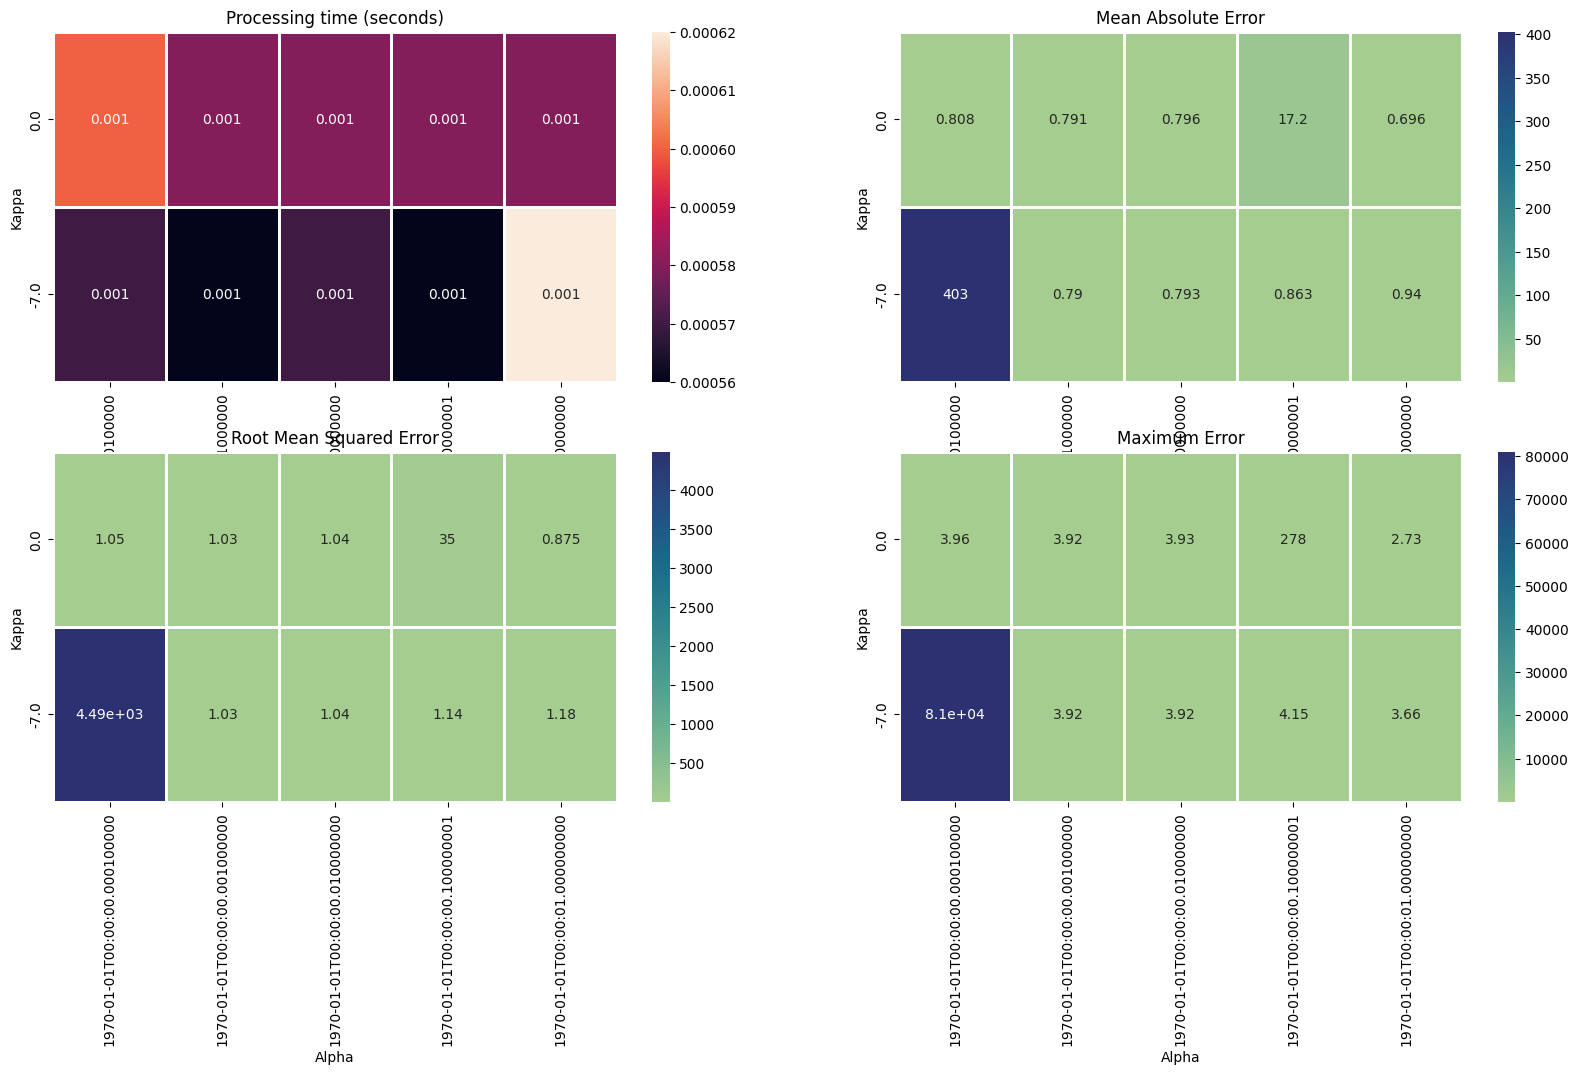

In [9]:
tuner_setup2.plot_results()

In [10]:
best_combination_setup2_0 = tuner_setup2.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.696
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 0.875
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 2.728
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------


## Setup3 (INS)

In [11]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.0, 
    gps_dropout_ratio=0.0,
    visualize_data=False)

tuner_setup3 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup3.run()
else:
    tuner_setup3.load_df()

Data sampling is set to normal mode.


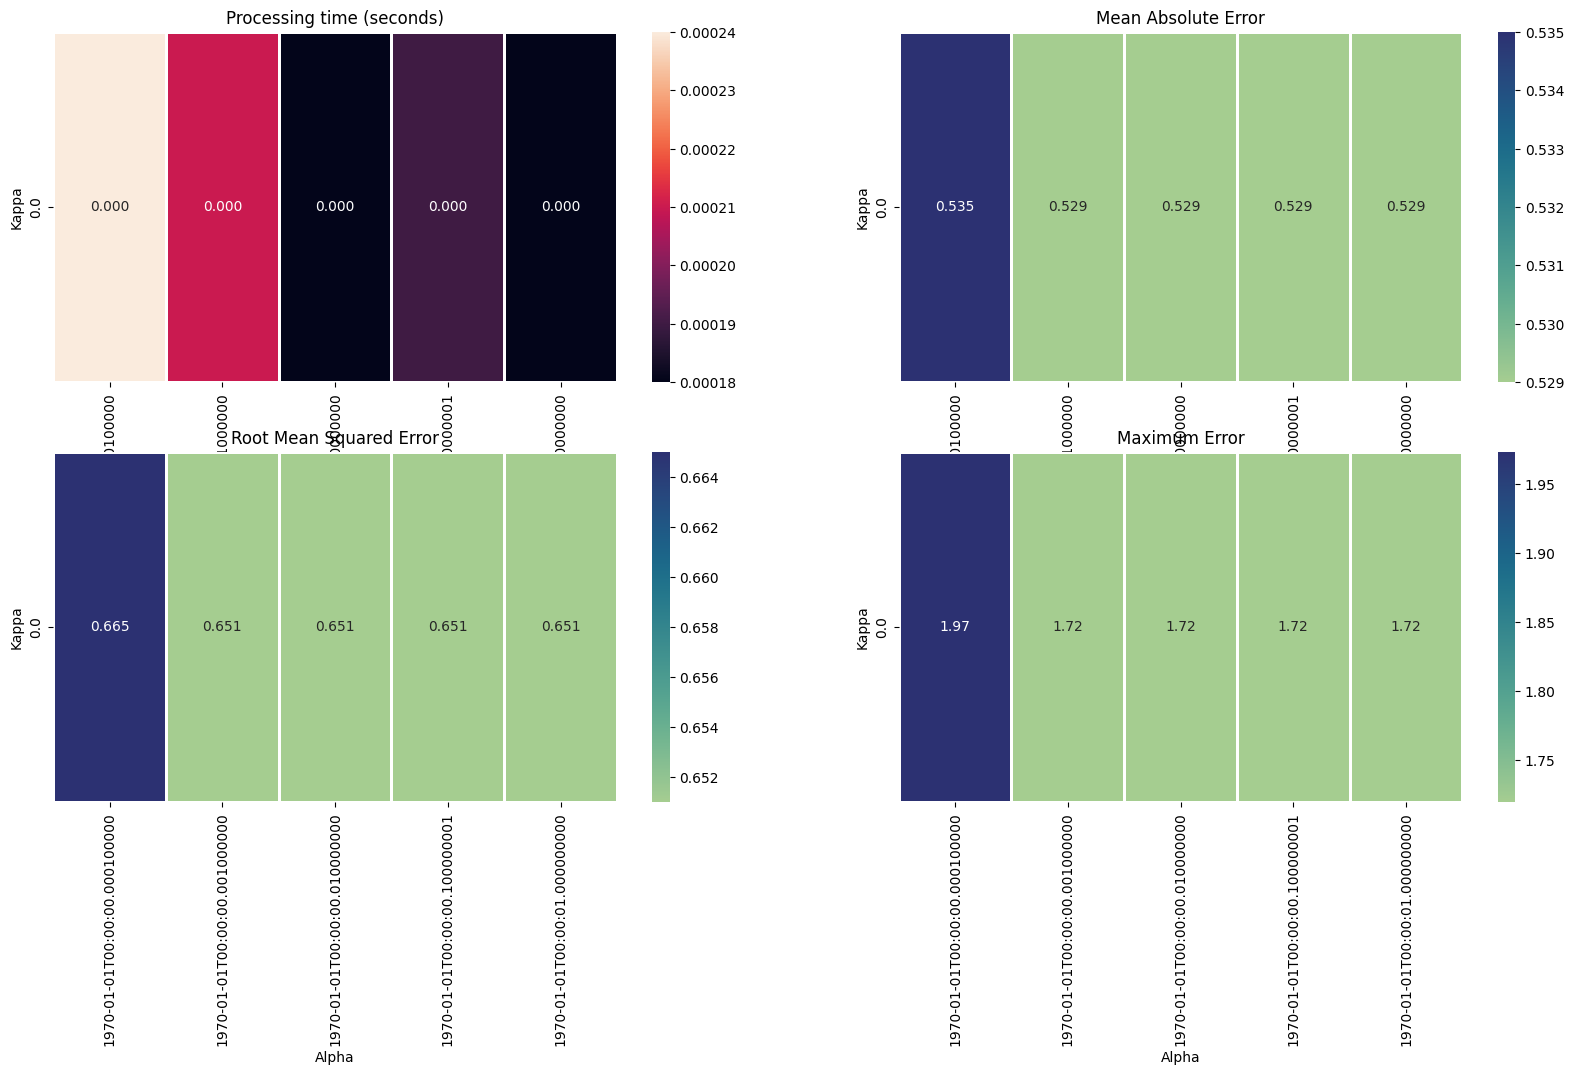

In [12]:
tuner_setup3.plot_results()

In [13]:
best_combination_setup3_0 = tuner_setup3.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.529
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 0.651
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 1.720
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------


## Best parameters

In [14]:
best_combination_setup1_0[error_type]

{'alpha': 0.1, 'kappa': 0.0}

In [15]:
best_combination_setup2_0[error_type]

{'alpha': 1.0, 'kappa': 0.0}

In [16]:
best_combination_setup3_0[error_type]

{'alpha': 0.001, 'kappa': 0.0}

# 10% dropout measurement data

In [17]:
vo_dropout_ratio = 0.1
gps_dropout_ratio = 0.1

## Setup1(IMU, VO)

In [18]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup1_10 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup1_10.run()
else:
    tuner_setup1_10.load_df()

Data sampling is set to normal mode.


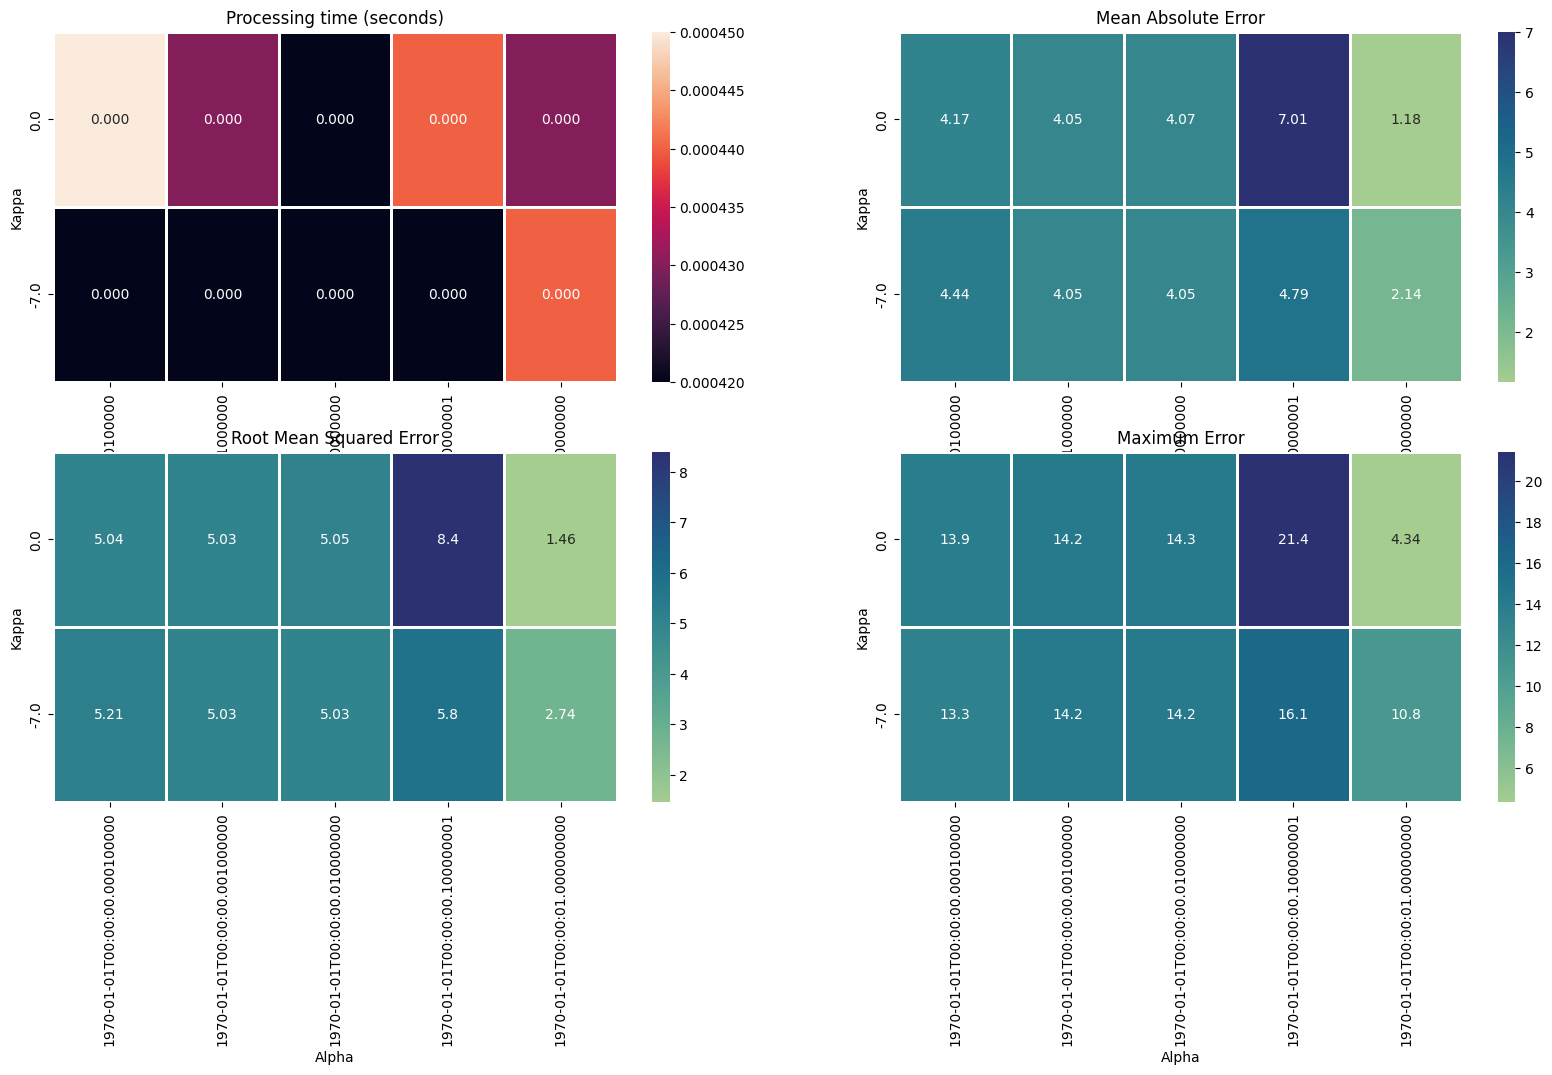

In [19]:
tuner_setup1_10.plot_results()

In [20]:
best_combination_setup1_10 = tuner_setup1_10.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 1.175
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 1.463
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 4.337
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------


## Setup2(IMU, VO+GPS)

In [21]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup2_10 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup2_10.run()
else:
    tuner_setup2_10.load_df()

Data sampling is set to normal mode.


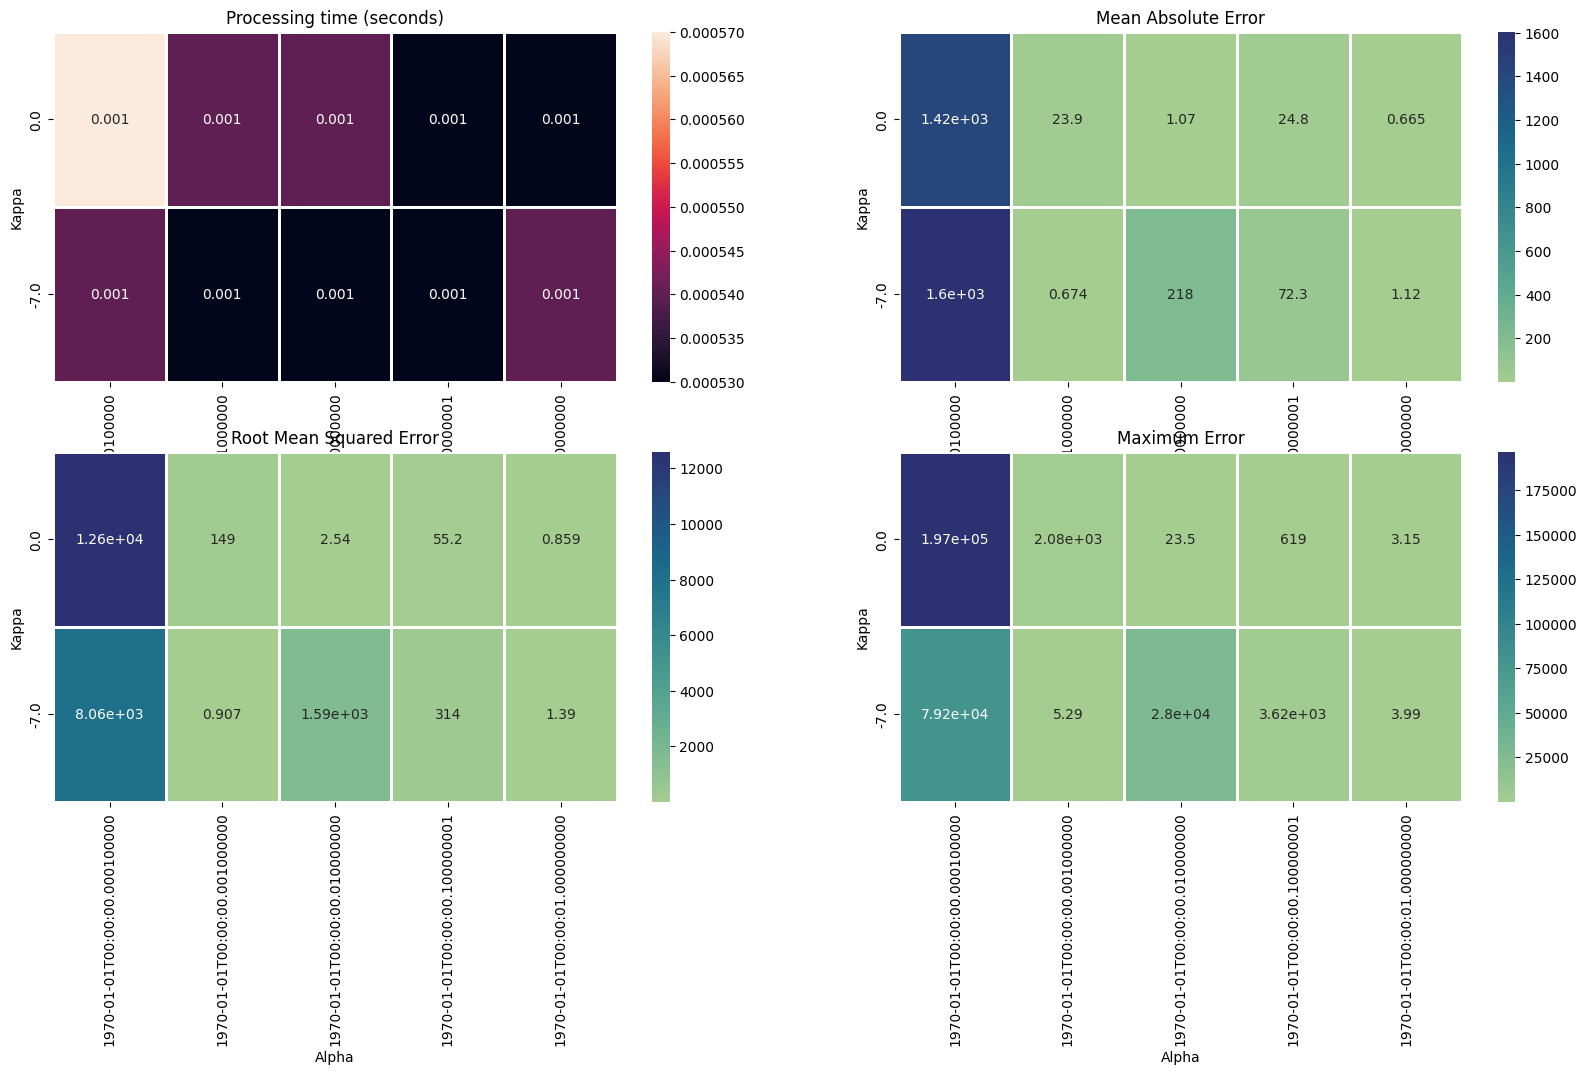

In [22]:
tuner_setup2_10.plot_results()

In [23]:
best_combination_setup2_10 = tuner_setup2_10.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.665
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 0.859
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 3.147
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------


## Setup3 (INS)

In [24]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio,
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup3_10 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup3_10.run()
else:
    tuner_setup3_10.load_df()

Data sampling is set to normal mode.


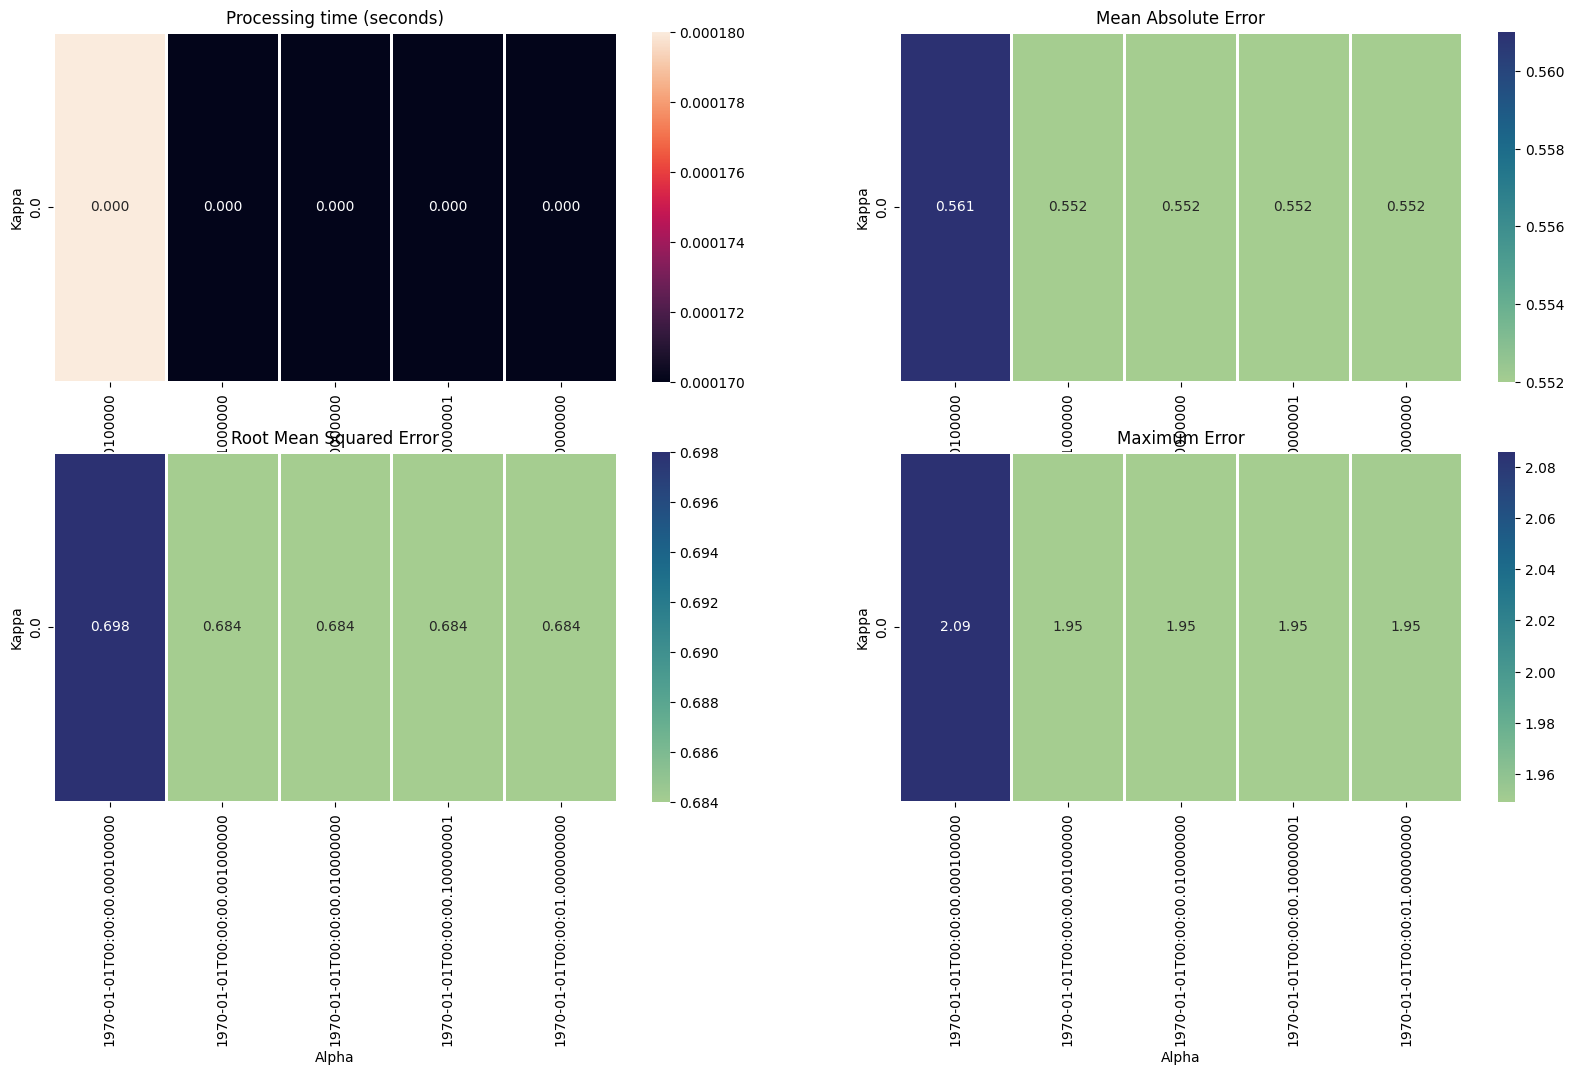

In [25]:
tuner_setup3_10.plot_results()

In [26]:
best_combination_setup3_10 = tuner_setup3_10.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.552
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 0.684
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 1.949
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------


## Best parameters

In [27]:
best_combination_setup1_10[error_type]

{'alpha': 1.0, 'kappa': 0.0}

In [28]:
best_combination_setup2_10[error_type]

{'alpha': 1.0, 'kappa': 0.0}

In [29]:
best_combination_setup3_10[error_type]

{'alpha': 0.001, 'kappa': 0.0}

# 20% dropout measurement data

In [30]:
vo_dropout_ratio = 0.2
gps_dropout_ratio = 0.2

## Setup1(IMU, VO)

In [31]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup1_20 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup1_20.run()
else:
    tuner_setup1_20.load_df()

Data sampling is set to normal mode.


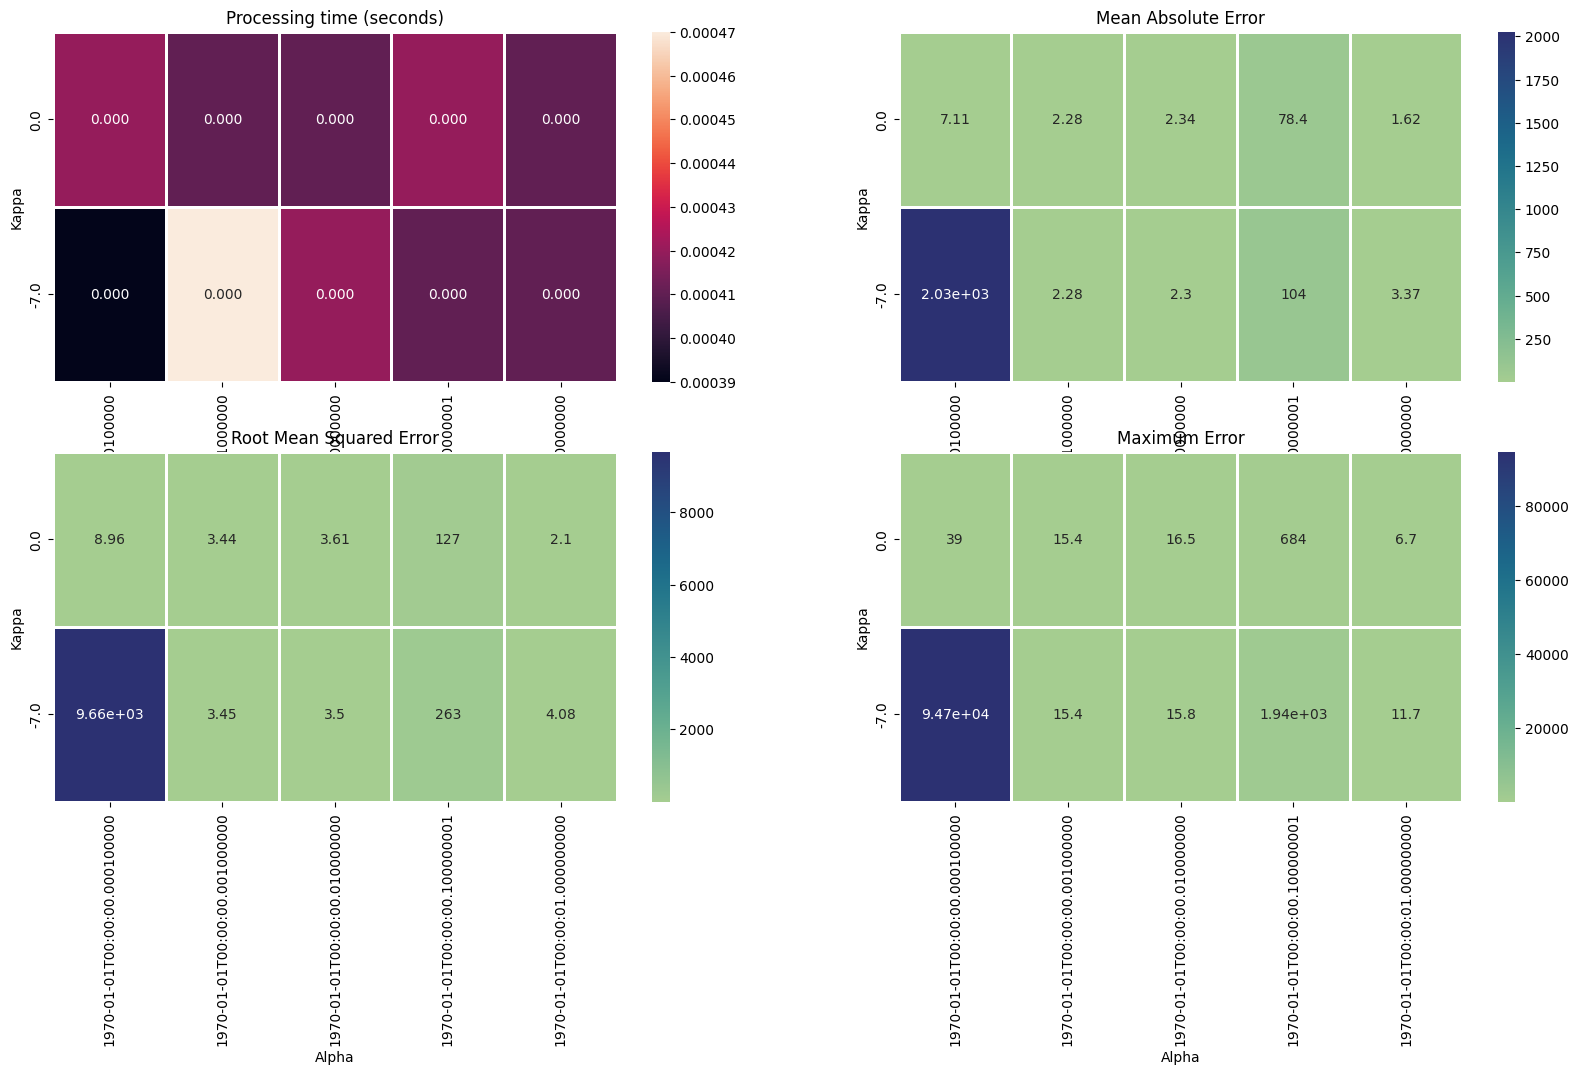

In [32]:
tuner_setup1_20.plot_results()

In [33]:
best_combination_setup1_20 = tuner_setup1_20.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 1.623
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 2.103
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 6.697
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------


## Setup2(IMU, VO+GPS)

In [34]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup2_20 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup2_20.run()
else:
    tuner_setup2_20.load_df()

Data sampling is set to normal mode.


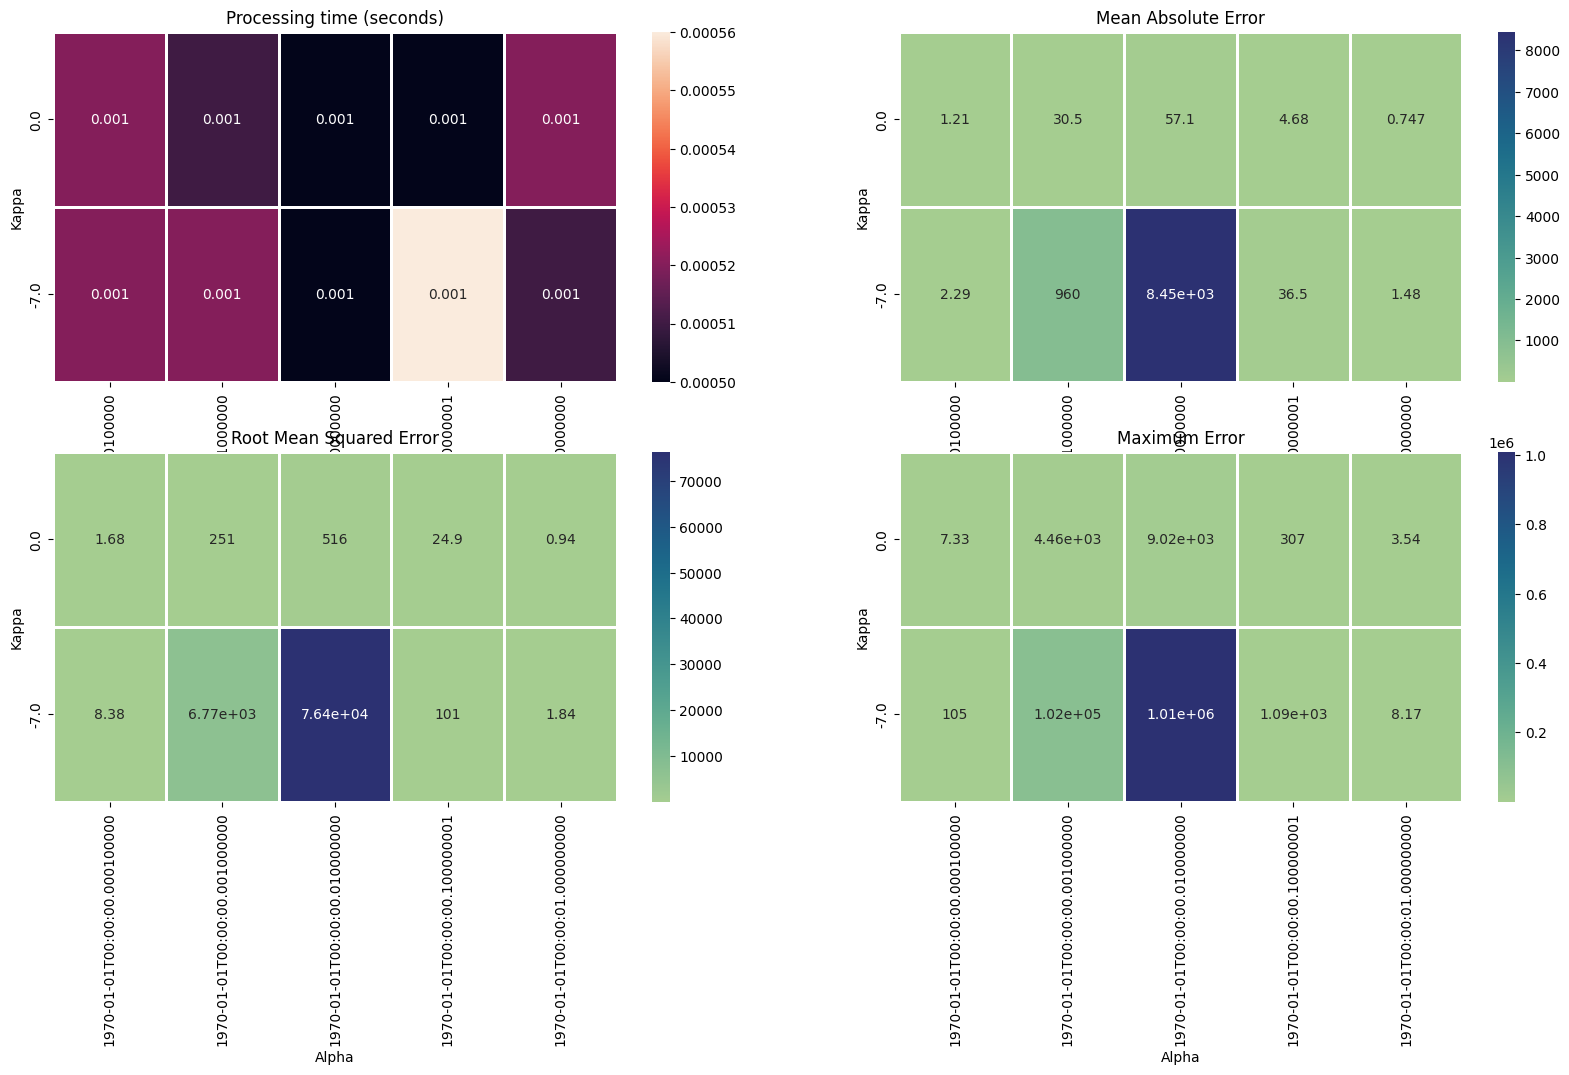

In [35]:
tuner_setup2_20.plot_results()

In [36]:
best_combination_setup2_20 = tuner_setup2_20.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.747
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 0.940
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 3.541
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------


## Setup3 (INS)

In [37]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup3_20 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup3_20.run()
else:
    tuner_setup3_20.load_df()

Data sampling is set to normal mode.


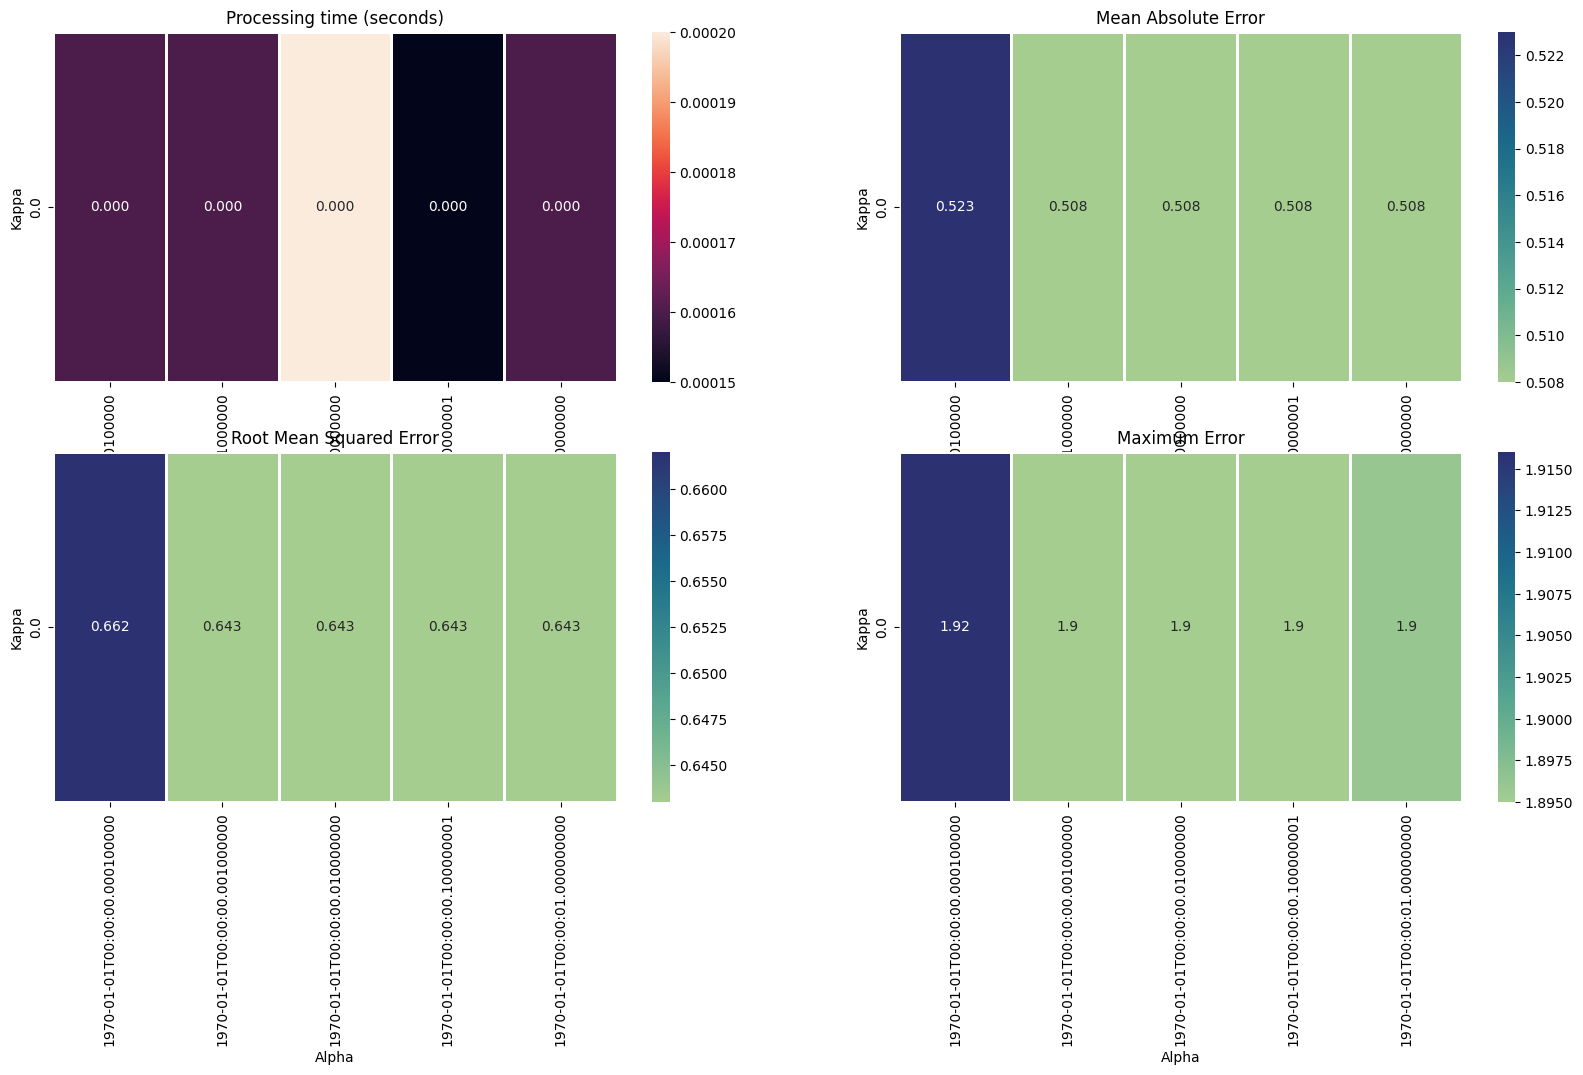

In [38]:
tuner_setup3_20.plot_results()

In [39]:
best_combination_setup3_20 = tuner_setup3_20.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.508
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 0.643
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 1.895
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------


## Best parameters

In [40]:
best_combination_setup1_20[error_type]

{'alpha': 1.0, 'kappa': 0.0}

In [41]:
best_combination_setup2_20[error_type]

{'alpha': 1.0, 'kappa': 0.0}

In [42]:
best_combination_setup3_20[error_type]

{'alpha': 0.001, 'kappa': 0.0}

# 30% dropout measurement data

In [43]:
vo_dropout_ratio = 0.3
gps_dropout_ratio = 0.3

## Setup1(IMU, VO)

In [44]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup1_30 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup1_30.run()
else:
    tuner_setup1_30.load_df()

Data sampling is set to normal mode.


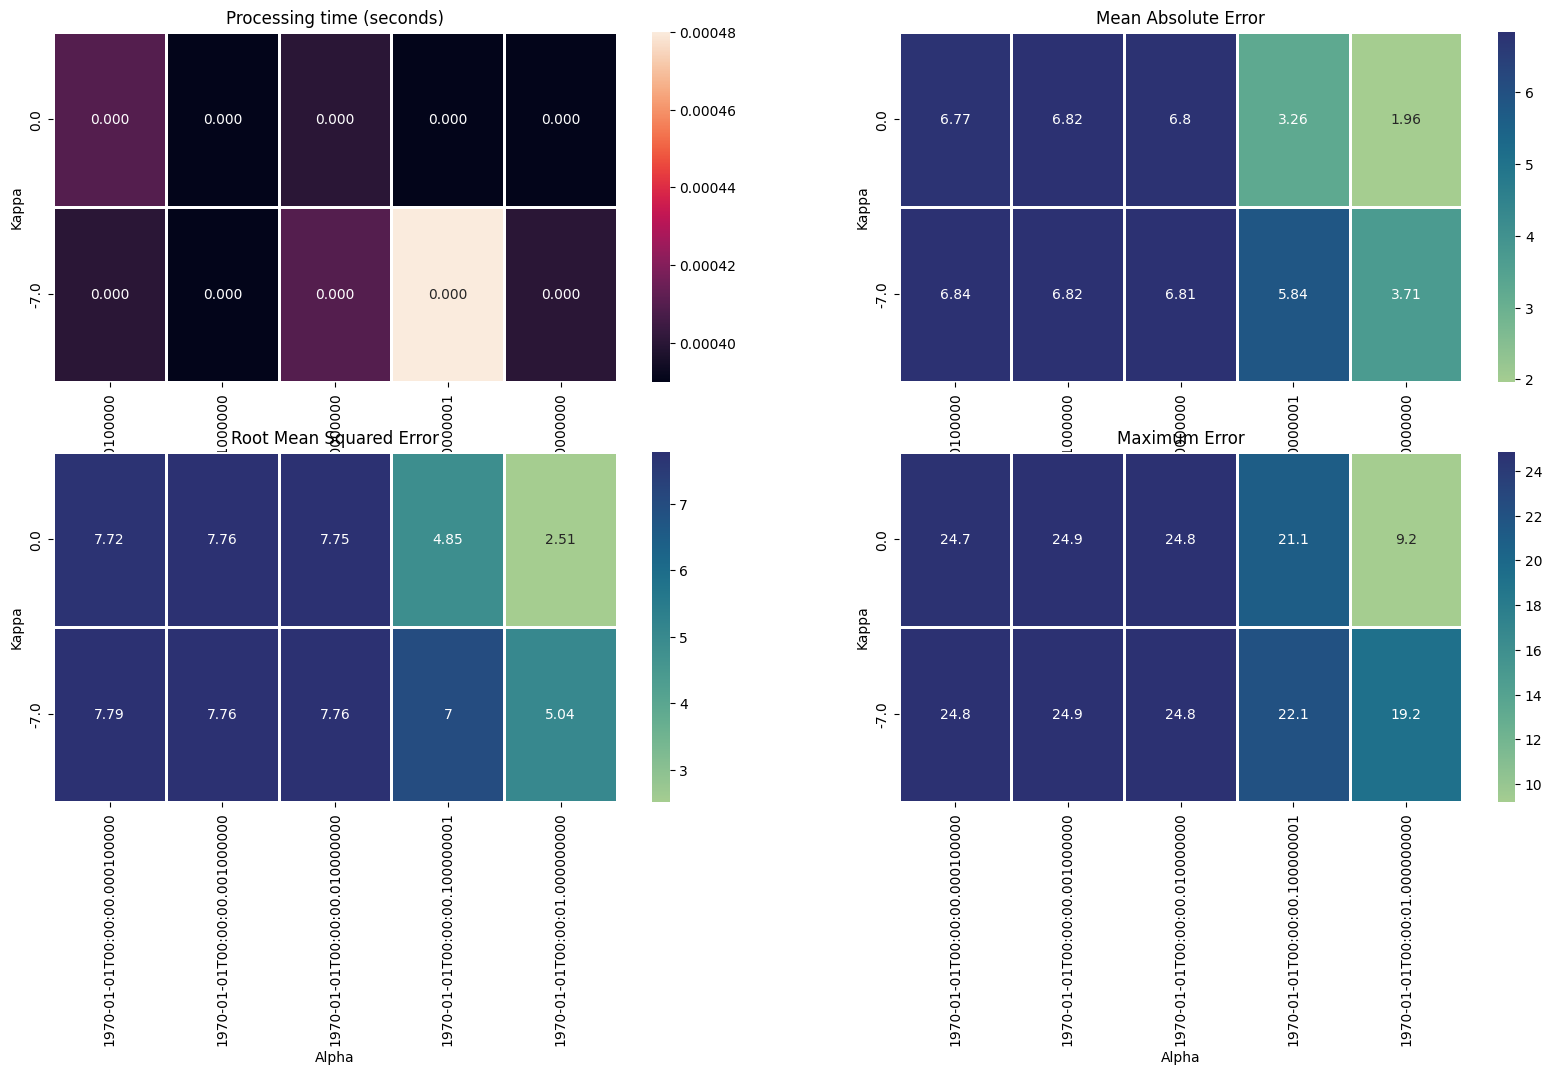

In [45]:
tuner_setup1_30.plot_results()

In [46]:
best_combination_setup1_30 = tuner_setup1_30.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 1.964
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 2.513
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 9.199
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------


## Setup2(IMU, VO+GPS)

In [47]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup2_30 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup2_30.run()
else:
    tuner_setup2_30.load_df()

Data sampling is set to normal mode.


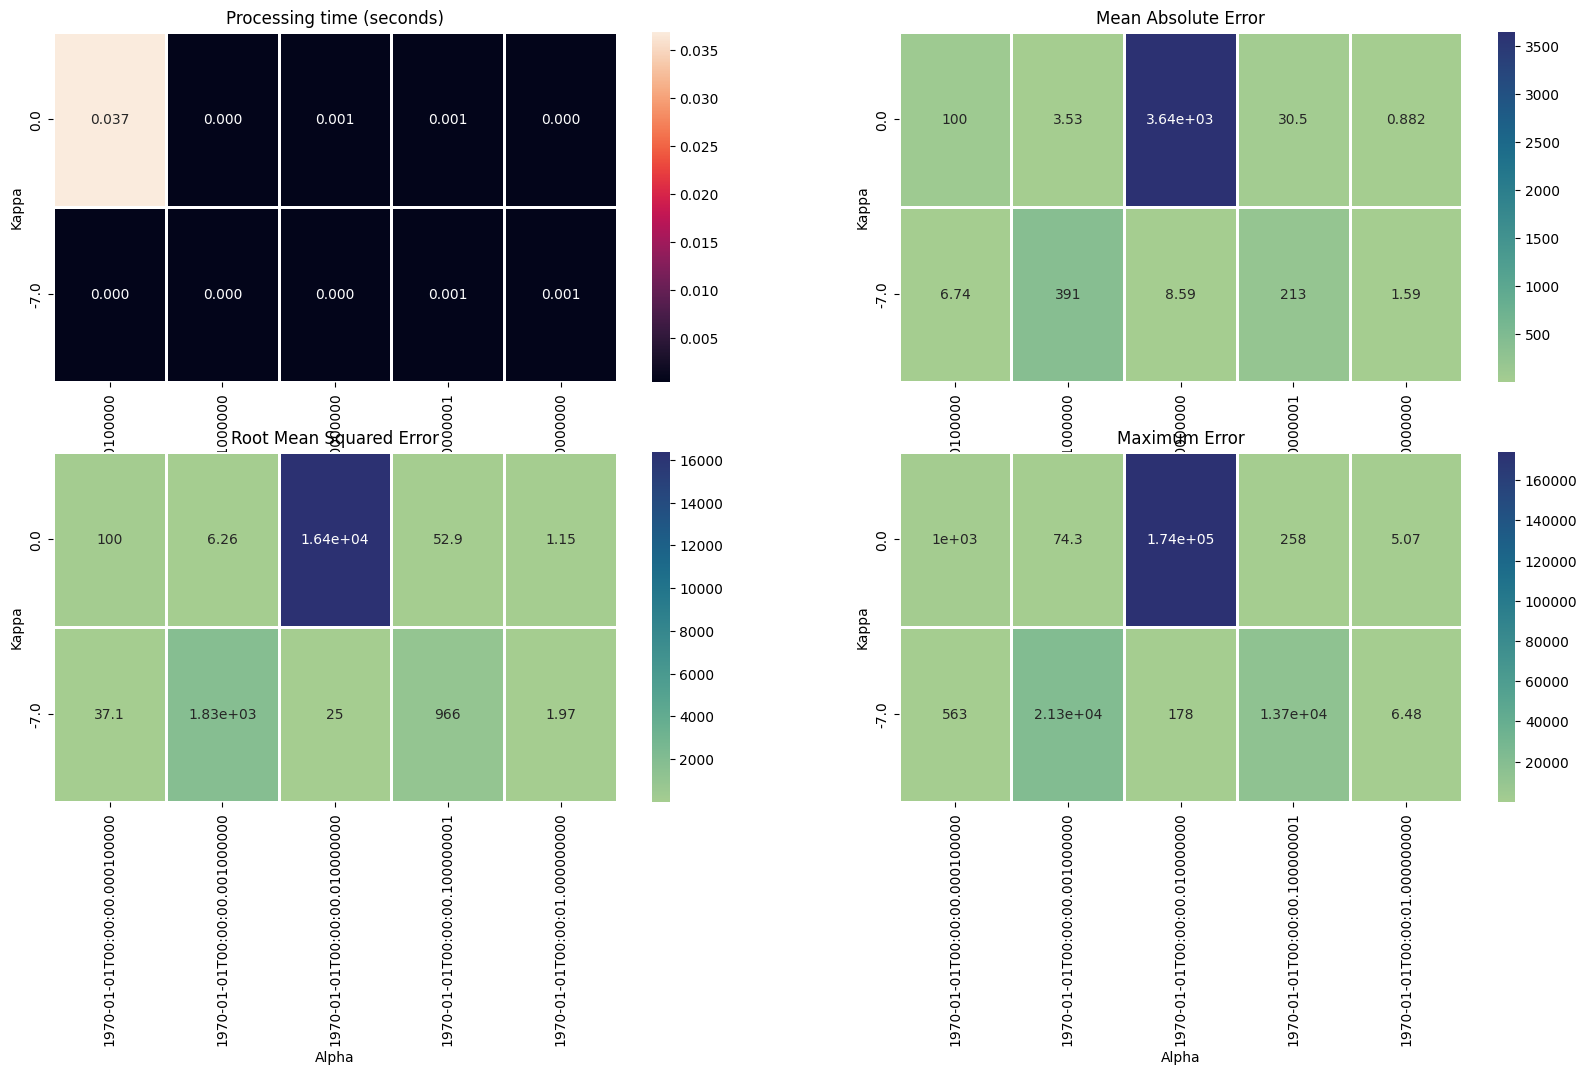

In [48]:
tuner_setup2_30.plot_results()

In [49]:
best_combination_setup2_30 = tuner_setup2_30.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.882
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 1.147
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 5.071
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------


## Setup3 (INS)

In [50]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup3_30 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup3_30.run()
else:
    tuner_setup3_30.load_df()

Data sampling is set to normal mode.


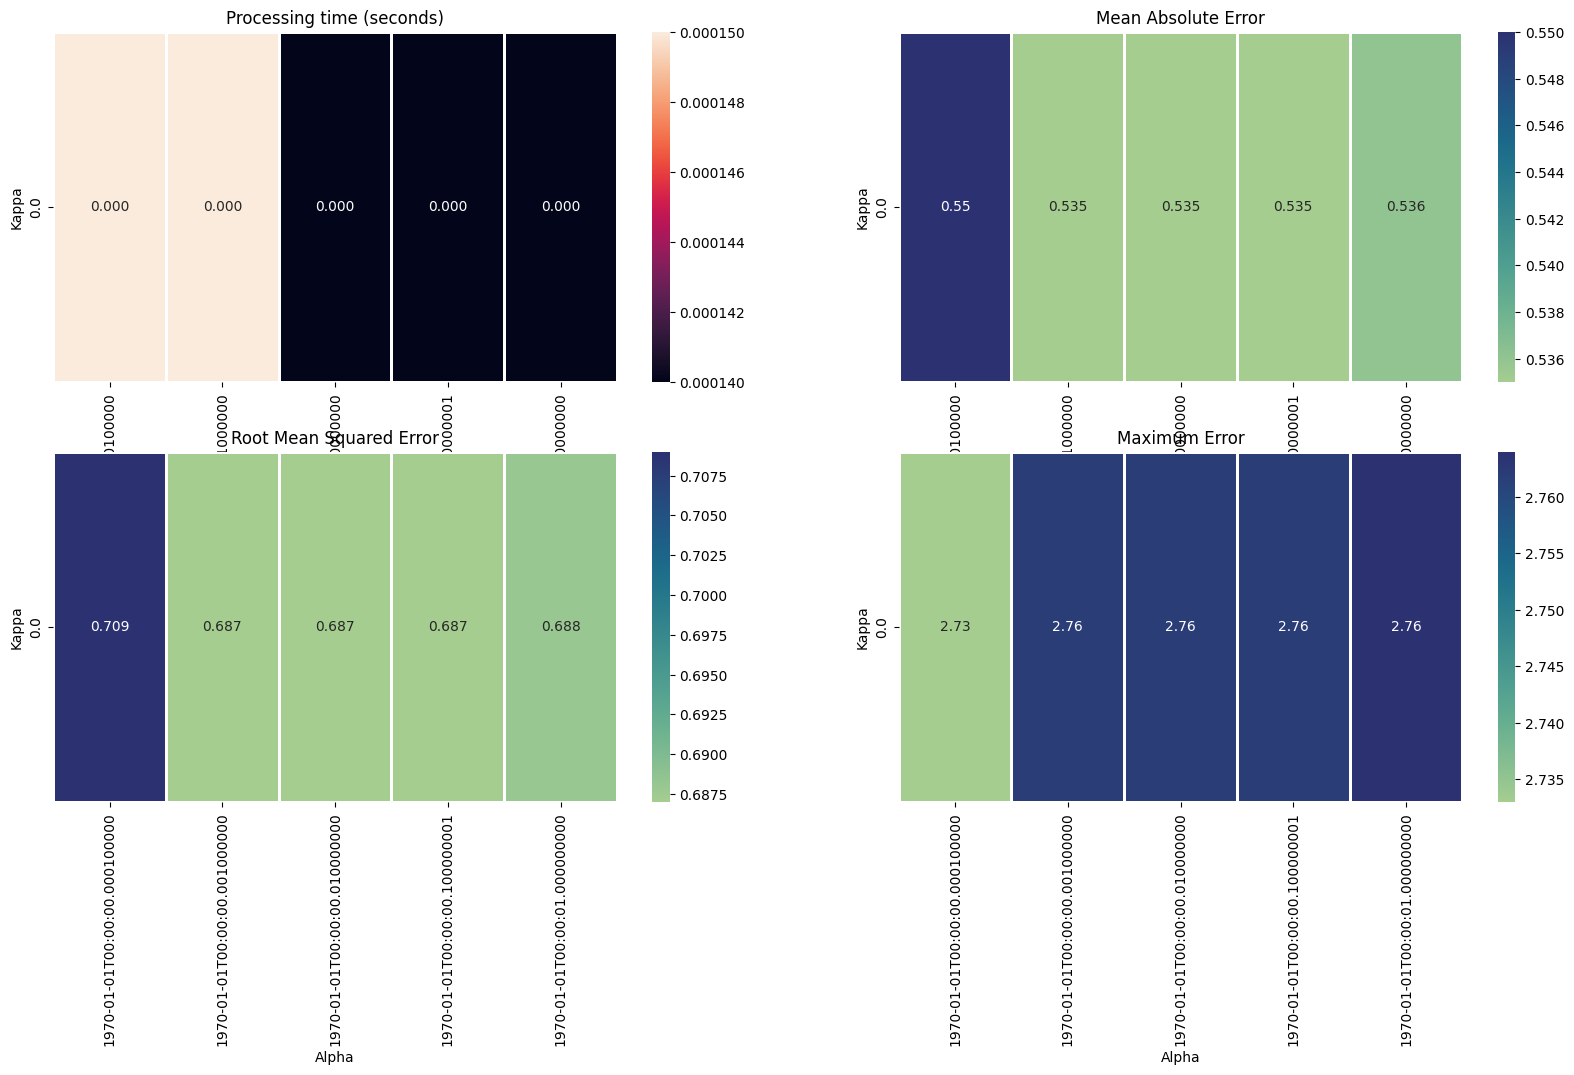

In [51]:
tuner_setup3_30.plot_results()

In [52]:
best_combination_setup3_30 = tuner_setup3_30.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.535
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 0.687
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 2.733
Processing time: 0.0
Alpha: 0.0001
Kappa: 0.0
--------------------


## Best parameters

In [53]:
best_combination_setup1_30[error_type]

{'alpha': 1.0, 'kappa': 0.0}

In [54]:
best_combination_setup2_30[error_type]

{'alpha': 1.0, 'kappa': 0.0}

In [55]:
best_combination_setup3_30[error_type]

{'alpha': 0.001, 'kappa': 0.0}

# 40% dropout measurement data

In [56]:
vo_dropout_ratio = 0.4
gps_dropout_ratio = 0.4

## Setup1(IMU, VO)

In [57]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup1_40 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup1_40.run()
else:
    tuner_setup1_40.load_df()

Data sampling is set to normal mode.


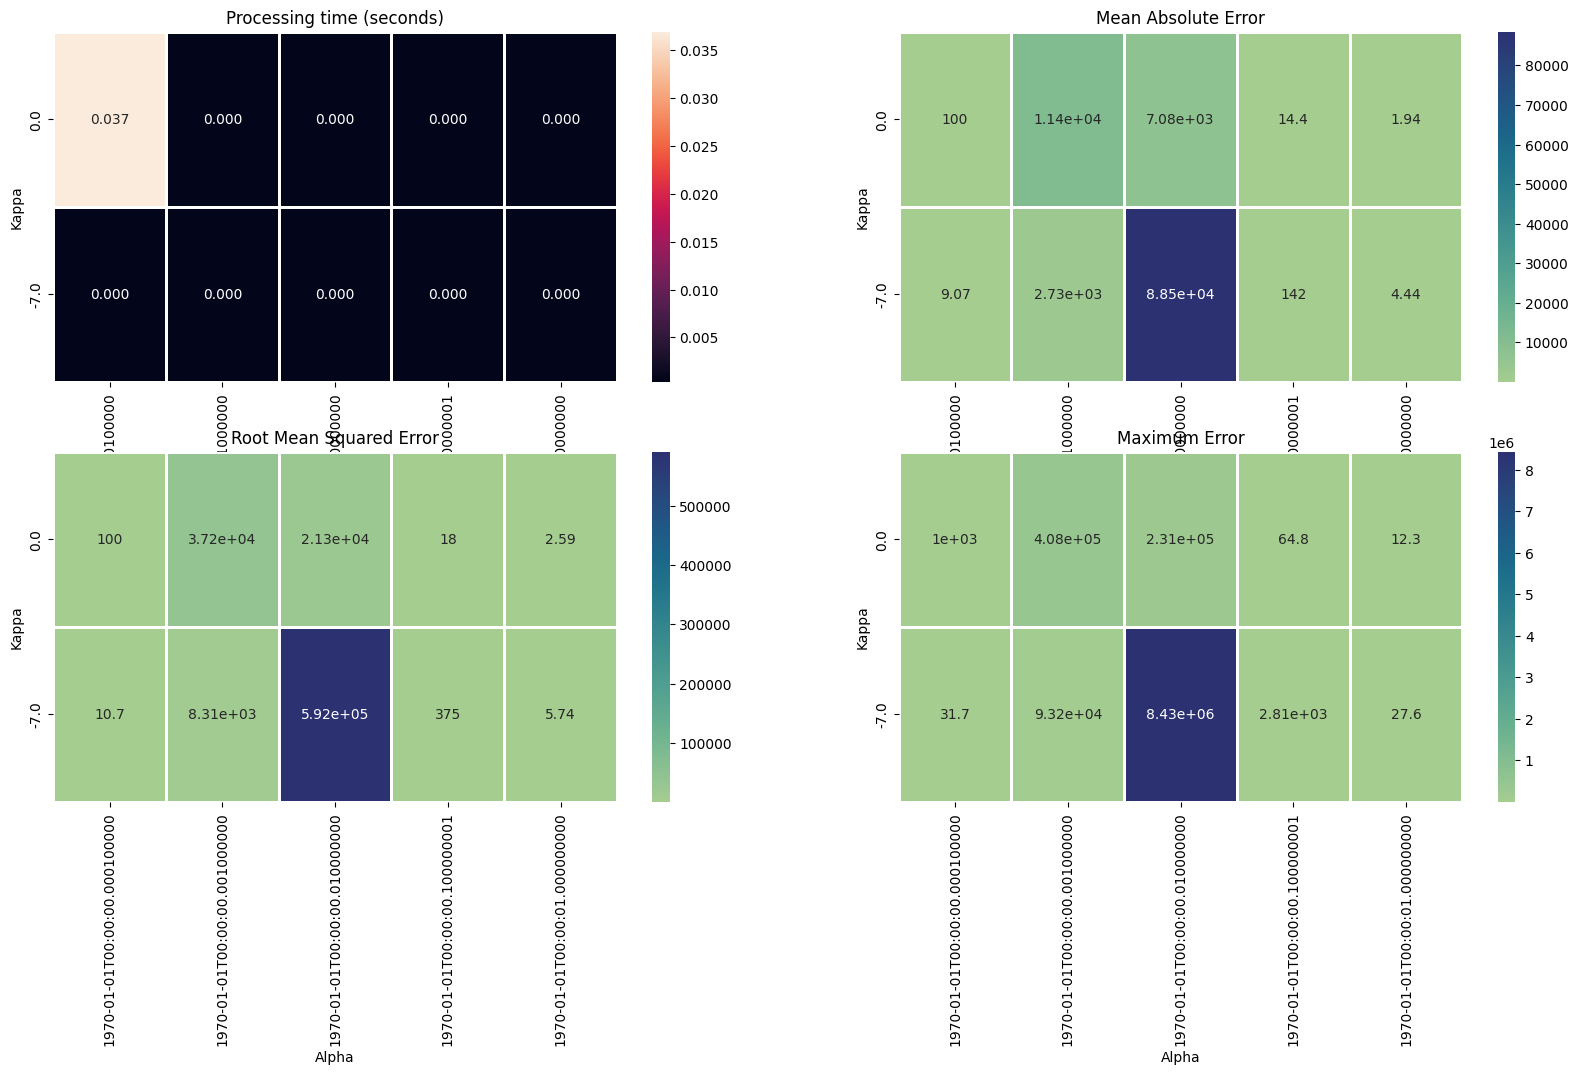

In [58]:
tuner_setup1_40.plot_results()

In [59]:
best_combination_setup1_40 = tuner_setup1_40.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 1.942
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 2.587
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 12.304
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------


## Setup2(IMU, VO+GPS)

In [60]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup2_40 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup2_40.run()
else:
    tuner_setup2_40.load_df()

Data sampling is set to normal mode.


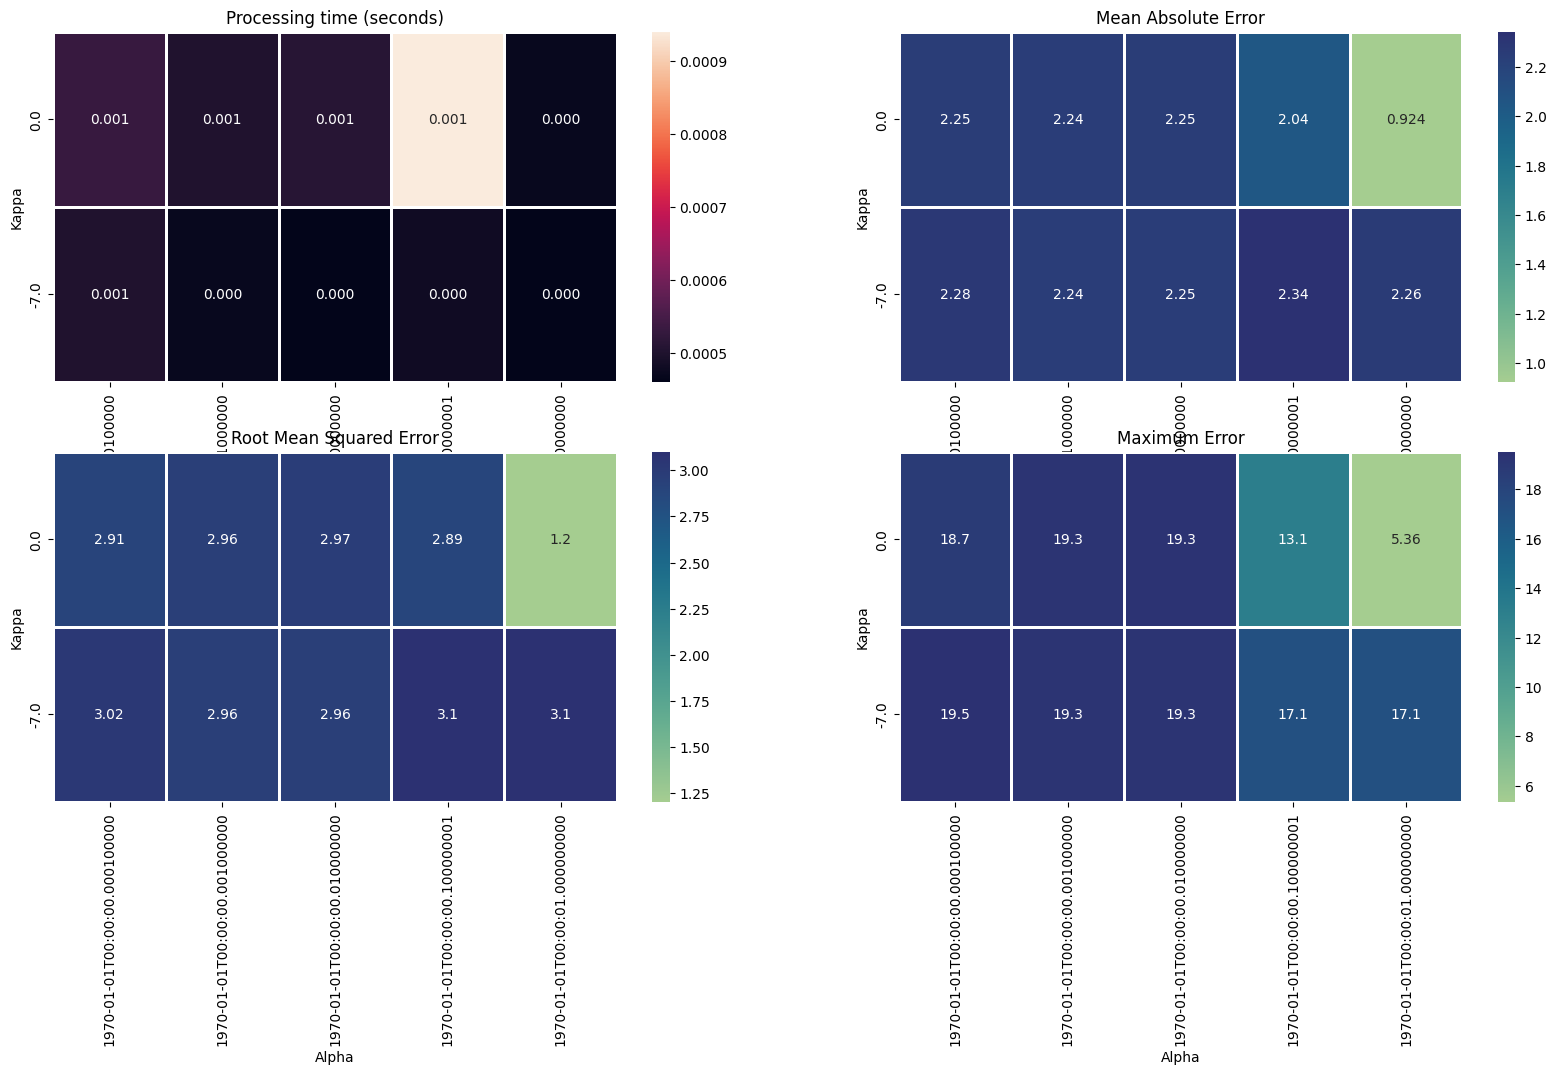

In [61]:
tuner_setup2_40.plot_results()

In [62]:
best_combination_setup2_40 = tuner_setup2_40.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.924
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 1.204
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 5.355
Processing time: 0.0
Alpha: 1.0
Kappa: 0.0
--------------------


## Setup3 (INS)

In [63]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False)

tuner_setup3_40 = UnscentedKalmanFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    file_export_path=file_export_path,
    kitti_drive=kitti_drive,
)
if run_filter:
    tuner_setup3_40.run()
else:
    tuner_setup3_40.load_df()

Data sampling is set to normal mode.


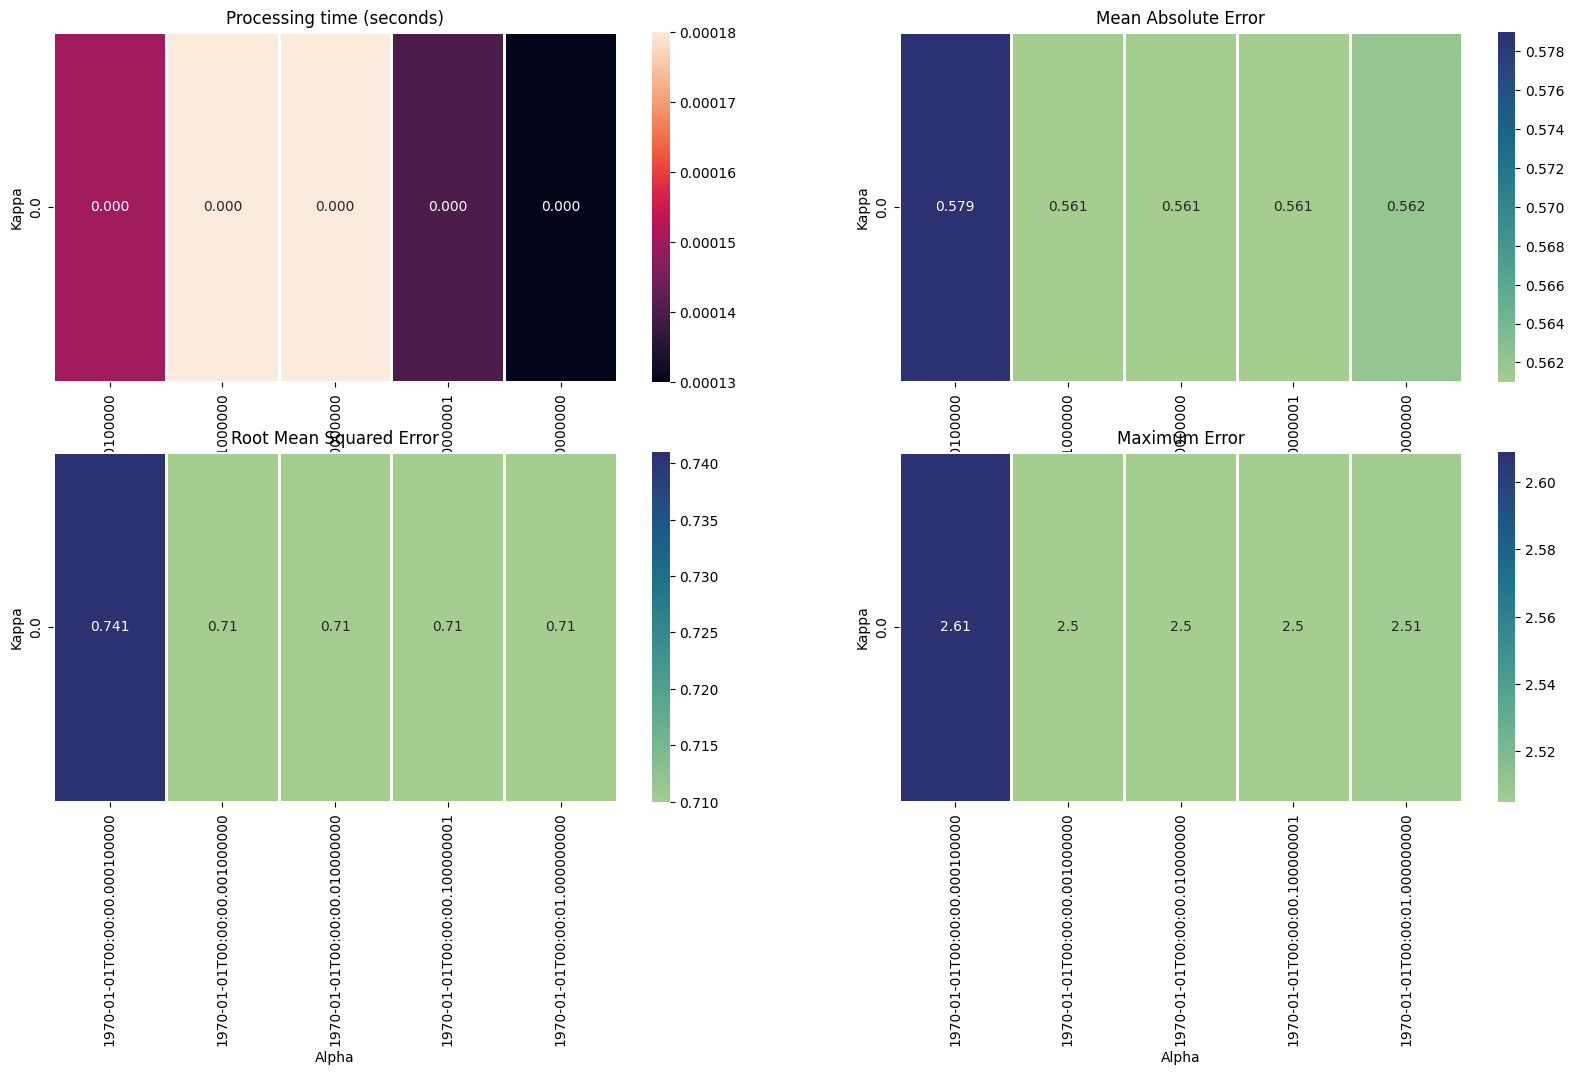

In [64]:
tuner_setup3_40.plot_results()

In [65]:
best_combination_setup3_40 = tuner_setup3_40.find_best_combination(error_weight=1., error_upper_limit=1000)

--------------------
Regarding MAE error:
Minimum MAE: 0.561
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding RMSE error:
Minimum MAE: 0.710
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------
Regarding MAX error:
Minimum MAE: 2.505
Processing time: 0.0
Alpha: 0.001
Kappa: 0.0
--------------------


## Best parameters

In [66]:
best_combination_setup1_40[error_type]

{'alpha': 1.0, 'kappa': 0.0}

In [67]:
best_combination_setup2_40[error_type]

{'alpha': 1.0, 'kappa': 0.0}

In [68]:
best_combination_setup3_40[error_type]

{'alpha': 0.001, 'kappa': 0.0}

# Results

In [69]:
best_combination_0 = [best_combination_setup1_0, best_combination_setup2_0, best_combination_setup3_0]
best_combination_10 = [best_combination_setup1_10, best_combination_setup2_10, best_combination_setup3_10]
best_combination_20 = [best_combination_setup1_20, best_combination_setup2_20, best_combination_setup3_20]
best_combination_30 = [best_combination_setup1_30, best_combination_setup2_30, best_combination_setup3_30]
best_combination_40 = [best_combination_setup1_40, best_combination_setup2_40, best_combination_setup3_40]

In [70]:
def get_best_parameters_by_dropout(best_combination):
    return np.array([
        [result[error_type]['alpha'], 2., result[error_type]['kappa']] for result in best_combination
    ]).flatten()

In [71]:
best_combination_0_arr = get_best_parameters_by_dropout(best_combination_0)
best_combination_10_arr = get_best_parameters_by_dropout(best_combination_10)
best_combination_20_arr = get_best_parameters_by_dropout(best_combination_20)
best_combination_30_arr = get_best_parameters_by_dropout(best_combination_30)
best_combination_40_arr = get_best_parameters_by_dropout(best_combination_40)

In [72]:
best_combination_0_arr

array([1.e-01, 2.e+00, 0.e+00, 1.e+00, 2.e+00, 0.e+00, 1.e-03, 2.e+00,
       0.e+00])

In [73]:
best_params = np.concatenate([
    best_combination_0_arr, best_combination_10_arr, best_combination_20_arr, best_combination_30_arr, best_combination_40_arr
]).reshape(5, 9)

In [74]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS)'],
                                             ['Alpha', 'Beta', 'Kappa']],
                                            names=['Setups','Parameters'])


In [75]:
best_params_df = pd.DataFrame(best_params, 
                    index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                    columns=results_header)

In [76]:
best_params_df

Setups     Setup1 (IMU, VO)            Setup2(IMU, VO+GPS)             \
Parameters            Alpha Beta Kappa               Alpha Beta Kappa   
No dropout              0.1  2.0   0.0                 1.0  2.0   0.0   
10% drop                1.0  2.0   0.0                 1.0  2.0   0.0   
20% drop                1.0  2.0   0.0                 1.0  2.0   0.0   
30% drop                1.0  2.0   0.0                 1.0  2.0   0.0   
40% drop                1.0  2.0   0.0                 1.0  2.0   0.0   

Setups     Setup3(INS)             
Parameters       Alpha Beta Kappa  
No dropout       0.001  2.0   0.0  
10% drop         0.001  2.0   0.0  
20% drop         0.001  2.0   0.0  
30% drop         0.001  2.0   0.0  
40% drop         0.001  2.0   0.0

In [77]:
best_params_df.to_json(exporting_filename)

# Conclusion

In this notebook, we applied manual search to find optimal parameters, alpha and kappa for Unscented Kalman Filter.
The optimal value for each parameter in each setup is:
- Setup1(IMU, VO):
  - alpha: 1.0
  - kappa: 0.0
- Setup2(IMU, VO+GPS):
  - alpha: 1.0
  - kappa: 0.0
- Setup3(INS, VO+GPS):
  - alpha: 0.001
  - kappa: 0.0

where, beta is set to 2.0 assuming that the distribution of the state is Gaussian.